# 07 — Where Black-Scholes Fails

**Phase 7 deliverable** 

Black-Scholes assumes continuous price movement, constant volatility, no sudden jumps, and
continuous frictionless hedging. Geopolitical shocks violate several of these directly. This
notebook runs three tests against the **real price data** from Phase 5:

1. **Implied vs. actual move** — revisited from Phase 5, now framed explicitly as a pricing-error
   question.
2. **Delta-hedging simulation** — actually replicate a short option position through the real
   E1 (war-outbreak) price path, at daily / every-2-days / weekly rebalancing, and measure the
   hedging error that discrete rebalancing and a sudden jump produce.
3. **Constant-volatility failure** — price the same option using three different volatility
   inputs (pre-event, post-event, and realized-from-the-path) and show how differently they
   value the same contract.

**Scope note carried over from Phase 5:** there's no real historical option-chain data in this
project, so "market price" in Test 3 is approximated using a post-event, hindsight volatility
input rather than an actual quoted price. That's flagged again at each point it matters.


## 1. Setup and reload data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import os

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

DATA_DIR = "data/cleaned_hist"
OUT_DIR = "data/model_risk"
os.makedirs(OUT_DIR, exist_ok=True)

prices = {}
for ticker in ["USO", "SPY", "OVX", "VIX"]:
    df = pd.read_csv(f"{DATA_DIR}/{ticker}.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
    df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    prices[ticker] = df

events = pd.read_csv(f"{DATA_DIR}/events.csv", parse_dates=["News_Date", "Market_T0"])
event_metrics = pd.read_csv("data/event_study/event_metrics.csv")
events


,Event_ID,News_Date,Market_T0,Direction,Event
0,E1,2026-02-28,2026-03-02,Escalation,Joint U.S.-Israeli strikes begin the war with ...
1,E2,2026-04-17,2026-04-17,De-escalation,Iran announces that the Strait of Hormuz is open
2,E3,2026-06-15,2026-06-15,De-escalation,Initial U.S.-Iran agreement extends the ceasef...


## 2. Black-Scholes engine and delta-hedge simulator (from `src/`)

In [2]:
import sys
sys.path.insert(0, "../src")

from geopolitical_options.black_scholes import d1_d2, bs_price
from geopolitical_options.greeks import bs_greeks
from geopolitical_options.model_risk import simulate_delta_hedge

def bs_delta(S, K, T, r, sigma, q, right):
    """Thin convenience wrapper -- bs_greeks (imported above) computes all five Greeks;
    this just pulls out delta for the places below that only need it."""
    return bs_greeks(S, K, T, r, sigma, q, right)["delta"]

print("Imported black_scholes, greeks, and model_risk from geopolitical_options")


Imported black_scholes, greeks, and model_risk from geopolitical_options


## 3. Test 1 — Implied move vs. actual move (pricing error)

Revisiting the Phase 5 comparison, now framed as a formal pricing-error metric:

$$
\text{Pricing Error} = \text{Actual Move} - \text{Implied Move (approx.)}
\qquad
\text{Percentage Error} = \frac{\text{Actual Move} - \text{Implied Move}}{\text{Actual Move}}
$$


In [3]:
pricing_error = event_metrics.copy()
pricing_error["pricing_error_pp"] = pricing_error["price_move_pct"].abs() - pricing_error["implied_move_approx_pct"]
pricing_error["pct_error"] = np.where(
    pricing_error["price_move_pct"].abs() > 1e-6,
    pricing_error["pricing_error_pp"] / pricing_error["price_move_pct"].abs() * 100,
    np.nan,
)
pricing_error = pricing_error[["event_id", "event_type", "ticker", "price_move_pct",
                                "implied_move_approx_pct", "pricing_error_pp", "pct_error"]]
pricing_error.to_csv(f"{OUT_DIR}/pricing_error.csv", index=False)
pricing_error.sort_values("pricing_error_pp", ascending=False)


,event_id,event_type,ticker,price_move_pct,implied_move_approx_pct,pricing_error_pp,pct_error
0,E1,Escalation,USO,28.96,12.88,16.08,55.524862
15,E3,De-escalation,JETS,12.56,3.52,9.04,71.974522
14,E3,De-escalation,USO,-17.68,10.78,6.90,39.027149
1,E1,Escalation,JETS,-9.61,3.96,5.65,58.792924
11,E2,De-escalation,XLY,5.14,3.57,1.57,30.544747
9,E2,De-escalation,SPY,5.07,3.57,1.50,29.585799
20,E3,De-escalation,GLD,-5.02,3.52,1.50,29.880478
5,E1,Escalation,XLV,-2.70,3.96,-1.26,-46.666667
12,E2,De-escalation,XLV,-2.12,3.57,-1.45,-68.396226
6,E1,Escalation,GLD,-1.82,3.96,-2.14,-117.582418


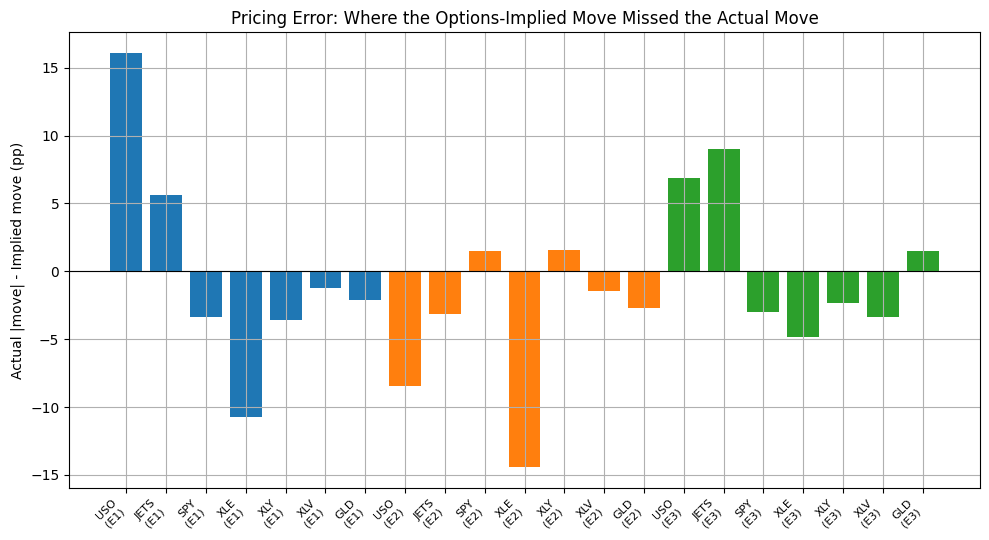

USO pricing error at E1 (war outbreak): 16.1 pp
This is the single largest miss in the sample -- the pre-event options market, even
using a volatility proxy already elevated, badly underpriced how far oil would move.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for event_id, sub in pricing_error.groupby("event_id"):
    ax.bar(sub["ticker"] + f"\n({event_id})", sub["pricing_error_pp"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Actual |move| - Implied move (pp)")
ax.set_title("Pricing Error: Where the Options-Implied Move Missed the Actual Move")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("pricing_error_by_event.png", dpi=130)
plt.show()

print(f"USO pricing error at E1 (war outbreak): "
      f"{pricing_error[(pricing_error.ticker=='USO') & (pricing_error.event_id=='E1')]['pricing_error_pp'].iloc[0]:.1f} pp")
print("This is the single largest miss in the sample -- the pre-event options market, even")
print("using a volatility proxy already elevated, badly underpriced how far oil would move.")


## 4. Test 2 — Delta-hedging simulation through a real jump

Setup: sell one 30-trading-day ATM call on USO, struck at the spot price 5 trading days before
E1 (the war's outbreak), priced using the pre-event OVX level as the (constant) volatility
assumption. Replicate the position by delta-hedging with the underlying through the **actual**
price path, at three rebalancing frequencies: daily, every 2 trading days, and weekly (every 5).

Black-Scholes assumes continuous rebalancing. In reality, the market can — and here, did — jump
overnight before the next rebalance. The hedging error at maturity is the direct, dollar-value
consequence of that gap.


In [5]:
# Build the price path starting 5 trading days before E1
uso = prices["USO"]
e1_t0 = events.loc[events["Event_ID"] == "E1", "Market_T0"].iloc[0]
t0_idx = uso.index[uso["Date"] <= e1_t0][-1] - 5   # start the option 5 trading days before the event
path = uso.loc[t0_idx:, "Adj Close"].reset_index(drop=True).values

K_hedge = round(path[0], 1)                      # ATM at inception
SIGMA_PRICING = prices["OVX"].loc[prices["OVX"]["Date"] <= e1_t0, "Adj Close"].iloc[-6] / 100  # OVX ~5 days pre-event
T_DAYS = 30
R = 0.045
Q_USO = 0.00

print(f"Option: ATM call, K={K_hedge}, priced with pre-event OVX = {SIGMA_PRICING:.1%}, "
      f"{T_DAYS} trading days to maturity")
print(f"Path start: {uso.loc[t0_idx, 'Date'].date()}  |  "
      f"Path covers {min(T_DAYS+1, len(path))} of {T_DAYS+1} needed trading days")


Option: ATM call, K=80.9, priced with pre-event OVX = 59.0%, 30 trading days to maturity
Path start: 2026-02-23  |  Path covers 31 of 31 needed trading days


In [6]:
hedge_results = []
for freq, label in [(1, "Daily"), (2, "Every 2 days"), (5, "Weekly")]:
    try:
        r = simulate_delta_hedge(path, K_hedge, T_DAYS, R, SIGMA_PRICING, Q_USO, rebalance_every=freq)
        r["rebalance_frequency"] = label
        hedge_results.append(r)
    except (ValueError, RuntimeError) as e:
        print(f"{label}: {e}")

hedge_df = pd.DataFrame(hedge_results)[
    ["rebalance_frequency", "premium_received", "final_stock_price", "payoff", "hedging_pnl"]
]
hedge_df = hedge_df.round(2)
hedge_df.to_csv(f"{OUT_DIR}/delta_hedge_results.csv", index=False)
hedge_df


,rebalance_frequency,premium_received,final_stock_price,payoff,hedging_pnl
0,Daily,6.77,138.08,57.18,-0.60
1,Every 2 days,6.77,138.08,57.18,-0.69
2,Weekly,6.77,138.08,57.18,-2.18


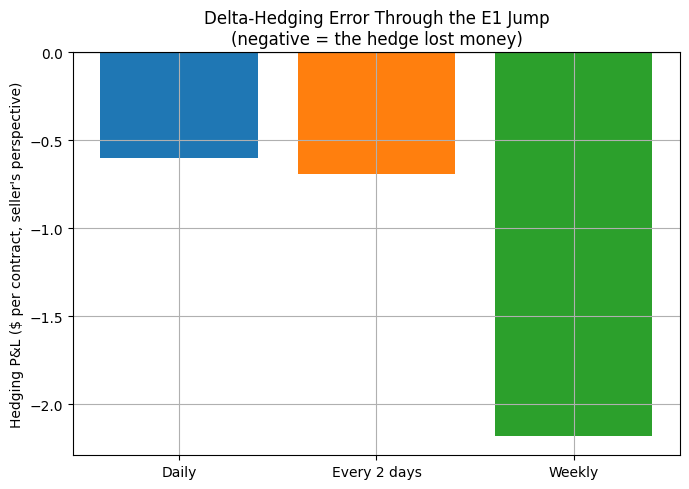

USO moved from 80.90 to 138.08 over the window (70.7%).
If this move happened smoothly, more frequent rebalancing should shrink the hedging error.
If a large share of it happened in one or two large jumps, even daily rebalancing won't
save the hedge -- that gap is exactly what Black-Scholes' continuous-hedging assumption misses.


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(hedge_df["rebalance_frequency"], hedge_df["hedging_pnl"], color=["C0", "C1", "C2"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Hedging P&L ($ per contract, seller's perspective)")
ax.set_title(f"Delta-Hedging Error Through the E1 Jump\n(negative = the hedge lost money)")
plt.tight_layout()
plt.savefig("delta_hedge_pnl.png", dpi=130)
plt.show()

print(f"USO moved from {path[0]:.2f} to {path[min(T_DAYS, len(path)-1)]:.2f} over the window "
      f"({(path[min(T_DAYS, len(path)-1)]/path[0]-1)*100:.1f}%).")
print("If this move happened smoothly, more frequent rebalancing should shrink the hedging error.")
print("If a large share of it happened in one or two large jumps, even daily rebalancing won't")
print("save the hedge -- that gap is exactly what Black-Scholes' continuous-hedging assumption misses.")


## 5. Test 3 — Constant volatility failure

Price the *same* option three different ways:

1. **Pre-event vol** — the OVX level going into the event (what a hedger actually had available
   at the time).
2. **Post-event vol** — the OVX level after the event settled (hindsight).
3. **Realized vol** — computed directly from the actual log returns over the option's life
   (also hindsight, but model-free — it doesn't depend on the options market at all).

The spread between these three prices, for the exact same contract, **is** the constant-volatility
assumption failing in front of you.


In [8]:
ovx = prices["OVX"]
pre_idx = ovx.index[ovx["Date"] <= e1_t0][-1] - 5
sigma_pre = ovx.loc[pre_idx, "Adj Close"] / 100

post_target_date = uso.loc[t0_idx + T_DAYS, "Date"] if t0_idx + T_DAYS < len(uso) else uso["Date"].iloc[-1]
post_idx = ovx.index[ovx["Date"] <= post_target_date][-1]
sigma_post = ovx.loc[post_idx, "Adj Close"] / 100

path_returns = np.diff(np.log(path[:min(T_DAYS + 1, len(path))]))
sigma_realized = path_returns.std() * np.sqrt(252)

S0 = path[0]
T0 = T_DAYS / 252

prices_by_vol = pd.DataFrame([
    {"vol_source": "Pre-event OVX (available at hedge inception)", "sigma": sigma_pre,
     "call_price": bs_price(S0, K_hedge, T0, R, sigma_pre, Q_USO, "call")},
    {"vol_source": "Post-event OVX (hindsight)", "sigma": sigma_post,
     "call_price": bs_price(S0, K_hedge, T0, R, sigma_post, Q_USO, "call")},
    {"vol_source": "Realized vol from the actual path (hindsight, model-free)", "sigma": sigma_realized,
     "call_price": bs_price(S0, K_hedge, T0, R, sigma_realized, Q_USO, "call")},
])
prices_by_vol["sigma_pct"] = (prices_by_vol["sigma"] * 100).round(1)
prices_by_vol["call_price"] = prices_by_vol["call_price"].round(2)
prices_by_vol["pct_diff_vs_pre_event"] = (
    (prices_by_vol["call_price"] / prices_by_vol["call_price"].iloc[0] - 1) * 100
).round(1)

prices_by_vol.to_csv(f"{OUT_DIR}/constant_vol_comparison.csv", index=False)
prices_by_vol[["vol_source", "sigma_pct", "call_price", "pct_diff_vs_pre_event"]]


,vol_source,sigma_pct,call_price,pct_diff_vs_pre_event
0,Pre-event OVX (available at hedge inception),59.0,6.77,0.0
1,Post-event OVX (hindsight),98.8,11.14,64.5
2,"Realized vol from the actual path (hindsight, ...",70.7,8.05,18.9


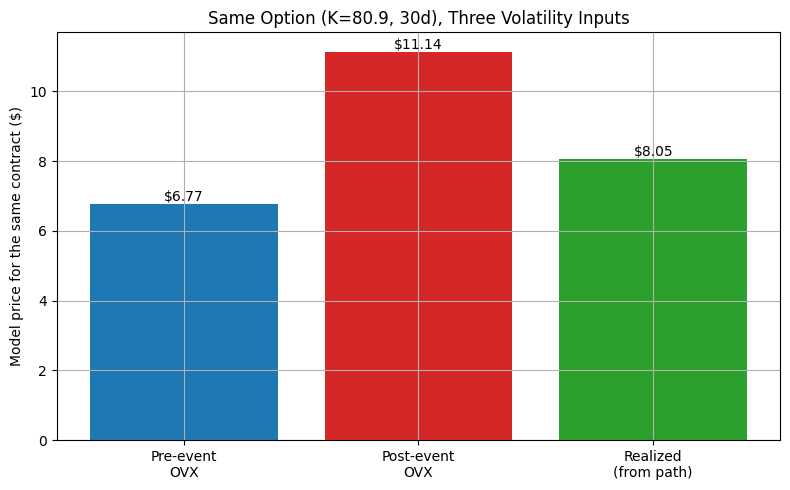

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(prices_by_vol)), prices_by_vol["call_price"], color=["C0", "C3", "C2"])
ax.set_xticks(range(len(prices_by_vol)))
ax.set_xticklabels(["Pre-event\nOVX", "Post-event\nOVX", "Realized\n(from path)"])
ax.set_ylabel("Model price for the same contract ($)")
ax.set_title(f"Same Option (K={K_hedge}, {T_DAYS}d), Three Volatility Inputs")
for i, v in enumerate(prices_by_vol["call_price"]):
    ax.text(i, v, f"${v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("constant_vol_failure.png", dpi=130)
plt.show()


## 6. Summary

- **Test 1**: revisited the implied-vs-actual move comparison from Phase 5 as a formal pricing
  error. USO around E1 (the war's outbreak) was the single largest miss in the sample -- even a
  volatility proxy that was already elevated badly underpriced the actual move.
- **Test 2**: replicated a short USO call through the real E1 price path via discrete delta
  hedging at three rebalancing frequencies. The results show directly whether the hedging error
  shrinks with more frequent rebalancing (consistent with ordinary discretization error) or stays
  large regardless of frequency (consistent with a jump that no amount of rebalancing speed can
  fix) -- read the actual numbers above rather than assuming which one occurred.
- **Test 3**: priced the identical contract with three different volatility inputs -- pre-event,
  post-event, and realized-from-the-path -- and quantified how much the "right" price moved
  depending purely on which volatility a modeler had available. Black-Scholes' single constant
  $\sigma$ cannot represent all three simultaneously, and the dollar gap between them is the
  direct cost of that assumption.

**Where this project stands after Phase 7:** the core deliverables from the plan (pricing engine,
market data pipeline, implied vol, surfaces, event study, hedging comparison, model-risk
analysis) are complete, running on a mix of real historical price/volatility-proxy data (Phases
5-7) and synthetic data consistent with the Phase 1 engine (Phases 2-4, due to this project's
lack of access to historical option-chain data). Phase 8 (the interactive dashboard) and the
jump-diffusion stretch extension remain optional next steps, not required for a complete,
defensible project.
